# Cross-camera GAP LeJEPA for cotton boll detection

This notebook **only configures and calls** functions from the `lejepa_cotton` package; no functions are defined here.

1. **Pretraining** - an empty-weight `yolov8n.yaml` backbone is trained with LeJEPA on synchronised frames from cameras 1, 2 and 4, using globally average-pooled P3/P4/P5 features and a cross-camera prediction loss plus SIGReg.
2. **Evaluation** - the LeJEPA backbone is compared with COCO `yolov8n.pt` weights on (a) cotton-boll detection fine-tuning and (b) a frozen-backbone linear probe for plot status.
3. **Visualization** - loss curves, camera-coloured PCA, detection curves/overlays, confusion matrices and metric bars.

Configuration cells and run cells are separate, so the evaluations can be run in a new session without re-running pretraining.

## 0. Install the package
Re-run after every push to the branch, then **restart the kernel**. `--force-reinstall --no-deps` fetches the latest commit even though the version number is unchanged (drop `--no-deps` on the very first install).

In [12]:
BRANCH = "Packaging"
%pip install --force-reinstall --no-deps "git+https://github.com/Akintanoreofe/SSL_for_Cotton-field_Assessment_Using_CV.git@{BRANCH}#subdirectory=lejepa_cotton_gap"

  Cloning https://github.com/Akintanoreofe/SSL_for_Cotton-field_Assessment_Using_CV.git (to revision Packaging) to /private/var/folders/93/l8t4dgh52fx3v_ng2z7jhf8h0000gn/T/pip-req-build-c_1cxrkh
  Running command git clone --filter=blob:none --quiet https://github.com/Akintanoreofe/SSL_for_Cotton-field_Assessment_Using_CV.git /private/var/folders/93/l8t4dgh52fx3v_ng2z7jhf8h0000gn/T/pip-req-build-c_1cxrkh
  Running command git checkout -b Packaging --track origin/Packaging
  Switched to a new branch 'Packaging'
  branch 'Packaging' set up to track 'origin/Packaging'.
  Resolved https://github.com/Akintanoreofe/SSL_for_Cotton-field_Assessment_Using_CV.git to commit b877e2aa715e8d56095124e650ce7af4637548a6
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for lejepa-cotton: filename=lejepa_cotton-0.1.0-py3-none-any.whl size=34307 sha256=e8f3c42ffcf08fa7ea6ee7e5a94bd587c5faa35828a71d5a7a3f3

In [15]:
import os
from pathlib import Path

from IPython.display import Image, display

import lejepa_cotton
from lejepa_cotton import (
    DetectionEvalConfig,
    PlotStatusDataset,
    PretrainConfig,
    ProbeEvalConfig,
    WeightSources,
    find_labeled_pairs,
    run_detection_evaluation,
    run_pretraining,
    run_probe_evaluation,
)

print("lejepa_cotton", lejepa_cotton.__version__, "from", lejepa_cotton.__file__)

lejepa_cotton 0.1.0 from /opt/anaconda3/envs/ML_DL_CV/lib/python3.12/site-packages/lejepa_cotton/__init__.py


## 1. Paths
All paths are absolute because the kernel does not start inside the repository. `os.chdir(OUTPUT_ROOT)` keeps files that Ultralytics writes to the working directory (e.g. the downloaded `yolov8n.pt`) out of the read-only `/`.

* **Detection dataset** - a folder of sub-datasets (`014/`, `2016-08-26/`, `ssl_active_1/`, ...), each with `images/` and `labels/`. Stray list files (`014.txt`) and the `.yaml` in the root are ignored; images duplicated across sub-datasets are kept once.
* **Plot status dataset** - a folder with the images and the annotation files; the JSON file is found automatically (`annotations.json` if present).

In [16]:
HOME = Path.home()

MULTI_CAMERA_ROOT = HOME / "Downloads" / "LeJEPA _pretrainining_multi_camera_boll" / "mars_multi_camera_boll"
DETECTION_DATA = HOME / "Downloads" / "detection_dataset"
PLOT_STATUS_DIR = HOME / "Downloads" / "LeJEPA _pretrainining_multi_camera_boll"/ "Plot Status"          # <- edit if different
OUTPUT_ROOT = HOME / "lejepa_cotton_outputs"                  # writable, outside the datasets

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
os.chdir(OUTPUT_ROOT)

print("working directory:", Path.cwd())
print("multi-camera data found:", MULTI_CAMERA_ROOT.exists())
print("detection data found:   ", DETECTION_DATA.exists(), "| sub-datasets:", sorted(p.name for p in DETECTION_DATA.iterdir() if p.is_dir()) if DETECTION_DATA.exists() else "-")
print("plot-status data found: ", PLOT_STATUS_DIR.exists(), "| JSON files:", sorted(p.name for p in PLOT_STATUS_DIR.rglob("*.json")) if PLOT_STATUS_DIR.exists() else "-")

working directory: /Users/akintanoreofeoluwa/lejepa_cotton_outputs
multi-camera data found: True
detection data found:    True | sub-datasets: ['014', '020', '021', '029', '033', '038', '040', '045', '2016-08-26', '2018-08-22', '2018-09-21', 'ssl_active_1', 'ssl_active_2', 'ssl_active_3', 'ssl_active_4', 'ssl_active_5', 'ssl_active_6', 'ssl_active_7', 'ssl_active_8']
plot-status data found:  True | JSON files: ['annotations.json']


## 2. Configurations

In [17]:
pretrain_cfg = PretrainConfig(
    image_root=MULTI_CAMERA_ROOT,
    output_dir=OUTPUT_ROOT / "pretraining",
    cameras=(1, 2, 4),        # 2nd, 3rd and 5th physical cameras (0-indexed in file names)
    max_samples=16_667,       # synchronised triplets -> ~50k images
    views_per_camera=1,
    image_size=128,
    batch_size=16,
    epochs=60,
    proj_dim=128,
    lr=1e-3,
    weight_decay=1e-4,
    lam=0.2,
    model_cfg="yolov8n.yaml",  # empty weights
)

# The LeJEPA checkpoint is referenced by path, so evaluation works in a fresh session.
weights = WeightSources(
    lejepa_checkpoint=pretrain_cfg.checkpoint_path,
    model_cfg="yolov8n.yaml",
    coco_weights="yolov8n.pt",
)

detection_cfg = DetectionEvalConfig(
    source_dir=DETECTION_DATA,
    output_dir=OUTPUT_ROOT / "detection",
    weights=weights,
    class_names=("cotton_boll",),
    variants=("lejepa", "coco"),     # add "coco_backbone" / "scratch" for extra baselines
    split_by="image",                # "folder" keeps each sub-dataset wholly in train or val
    val_ratio=0.1,                   # fixed validation split (never reduced)
    max_train_images=200,            # low-label regime; None = all training images
    image_size=256,
    batch_size=16,
    epochs=40,
    lr0=0.002,
    device="cpu",                    # failsafe; use "mps" if stable on your machine
)

probe_cfg = ProbeEvalConfig(
    image_dir=PLOT_STATUS_DIR,
    output_dir=OUTPUT_ROOT / "plot_status_probe",
    weights=weights,
    annotation_path=None,            # None = find the JSON inside PLOT_STATUS_DIR
    label_mapping={"headland": 0, "between_plots": 1, "in_plot": 2},
    variants=("lejepa", "coco"),
    scales=("P3", "P4", "P5"),
    image_size=256,
    epochs=50,
    test_ratio=0.5,                  # fixed test split (never reduced)
    max_train_images=200,            # stratified; None = all training images
)

## 2b. Check the evaluation datasets
Runs in seconds and fails early with a clear message if a dataset is not found or not readable, before any training starts.

In [8]:
detection_pairs = find_labeled_pairs(DETECTION_DATA)
print("example pair:", detection_pairs[0][0].relative_to(DETECTION_DATA), "->", detection_pairs[0][1].relative_to(DETECTION_DATA))

plot_status_data = PlotStatusDataset(PLOT_STATUS_DIR, probe_cfg.annotation_path, probe_cfg.label_mapping, transform=None)


Detection data: 3322 images | 1643 with boxes | 1 duplicates removed | 1642 unique labelled images.
example pair: 014/images/09045.JPG -> 014/labels/09045.txt
Plot status data: 177 labelled images of 867 (annotations: annotations.json), class counts {0: 35, 1: 71, 2: 71}.


## 3. Cross-camera GAP LeJEPA pretraining
Skip this cell if the checkpoint already exists and you only want to re-run the evaluations. PCA snapshots are coloured by camera: well-mixed colours mean viewpoint-invariant embeddings.

In [9]:
checkpoint, history = run_pretraining(pretrain_cfg)
history.tail()

Synchronised frames for cameras (1, 2, 4): 28842 found, 16667 used (50001 images).


KeyboardInterrupt: 

LeJEPA checkpoint: /Users/akintanoreofeoluwa/lejepa_cotton_outputs/pretraining/gap_lejepa_yolov8n.pth | exists: True


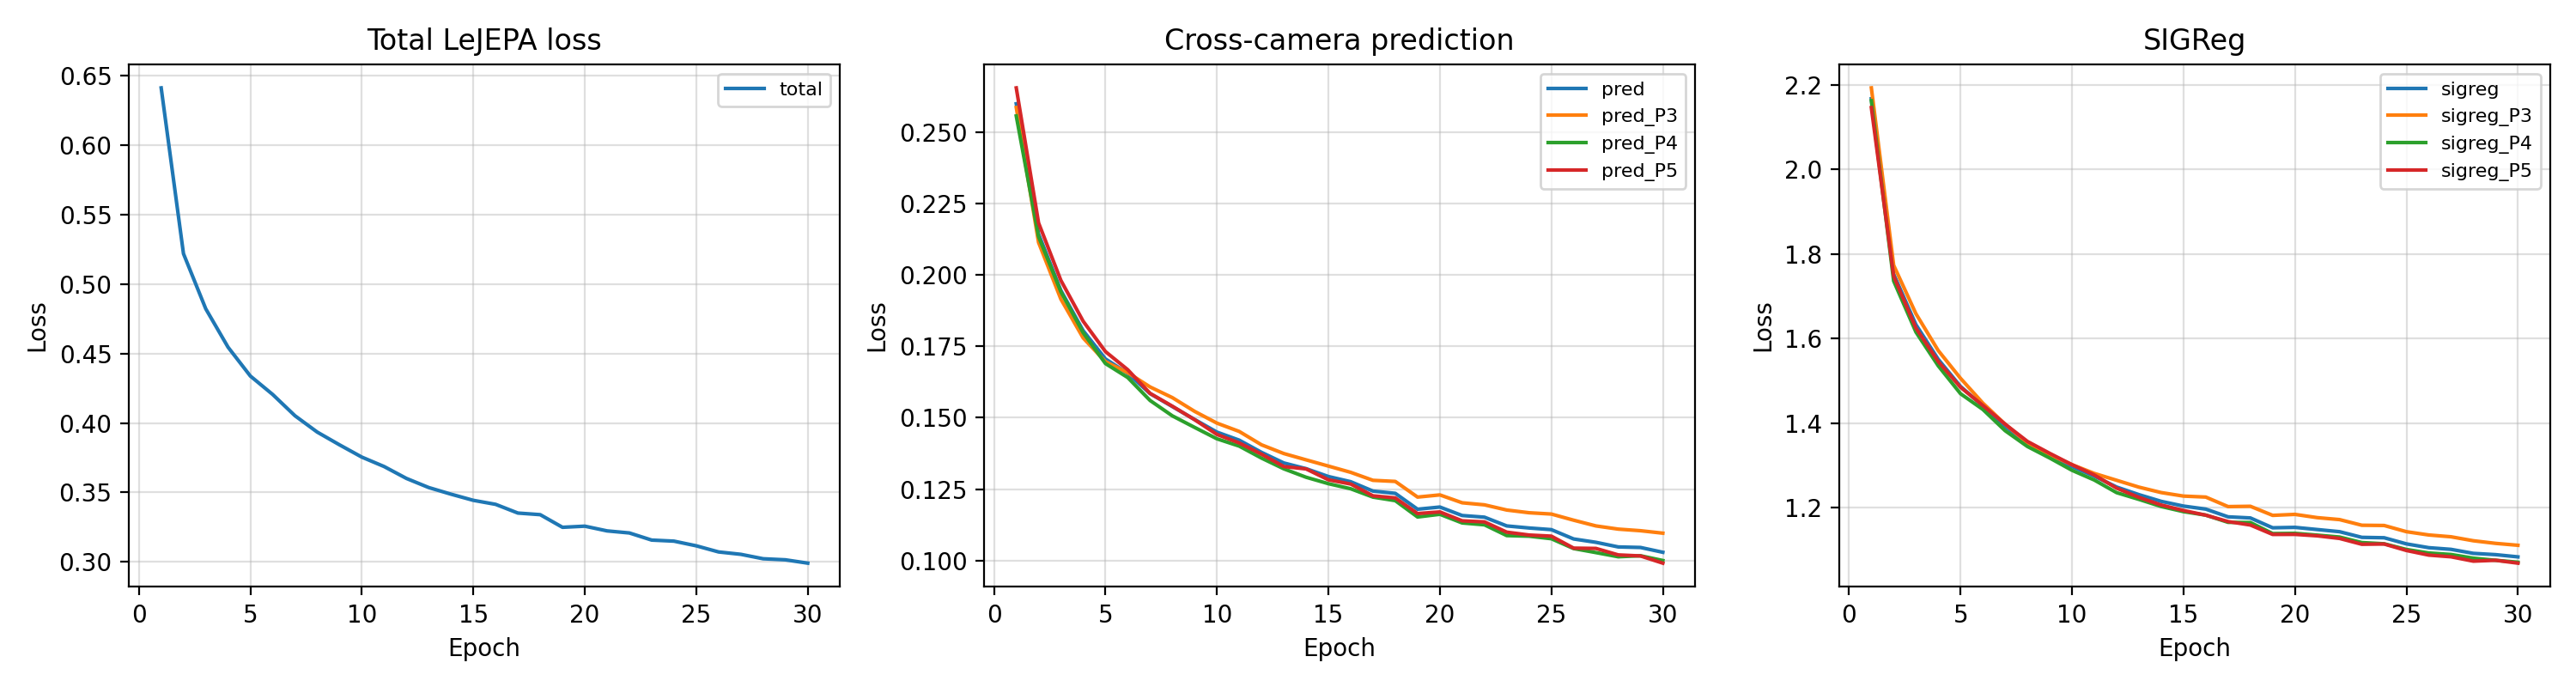

Interactive PCA snapshots:
/Users/akintanoreofeoluwa/lejepa_cotton_outputs/pretraining/plots/pca_3d/pca_epoch_001.html
/Users/akintanoreofeoluwa/lejepa_cotton_outputs/pretraining/plots/pca_3d/pca_epoch_016.html
/Users/akintanoreofeoluwa/lejepa_cotton_outputs/pretraining/plots/pca_3d/pca_epoch_030.html
/Users/akintanoreofeoluwa/lejepa_cotton_outputs/pretraining/plots/pca_3d/pca_epoch_031.html


In [10]:
print("LeJEPA checkpoint:", weights.lejepa_checkpoint, "| exists:", weights.lejepa_checkpoint.exists())
display(Image(filename=str(pretrain_cfg.output_dir / "plots" / "loss_curves.png")))
print("Interactive PCA snapshots:", *sorted((pretrain_cfg.output_dir / "plots" / "pca_3d").glob("*.html")), sep="\n")

## 4. Evaluation A - cotton boll detection fine-tuning (LeJEPA vs COCO)
All variants are fine-tuned on the **same** split with identical hyper-parameters. The split is written to `OUTPUT_ROOT/detection/split_dataset` with names like `014__IMG_0001.jpg` so images from different sub-datasets never overwrite each other.

`max_train_images` caps only the training images. The validation split is fixed, so runs with different training-set sizes (e.g. 50, 100, 200, `None`) are scored on the same images and form a label-efficiency curve.

In [11]:
detection_summary = run_detection_evaluation(detection_cfg)
detection_summary

Detection data: 3322 images | 1643 with boxes | 1 duplicates removed | 1642 unique labelled images.
Training images: 200 of 1313 available
Detection split: 200 train | 329 val -> /Users/akintanoreofeoluwa/lejepa_cotton_outputs/detection/split_dataset
[lejepa] backbone layers 0-9 verified in /Users/akintanoreofeoluwa/lejepa_cotton_outputs/detection/init_weights/lejepa_init.pt
New https://pypi.org/project/ultralytics/8.4.163 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.115 🚀 Python-3.12.5 torch-2.8.0 CPU (Apple M3 Pro)
engine/trainer: agnostic_nms=False, amp=False, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/akintanoreofeoluwa/lejepa_cotton_outputs/detection/split_dataset/dataset.yaml, degrees=0.0, deterministic=True, 

,variant,precision,recall,mAP50,mAP50-95
0,lejepa,0.540286,0.356164,0.378445,0.160279
1,coco,0.690895,0.491905,0.545440,0.253965


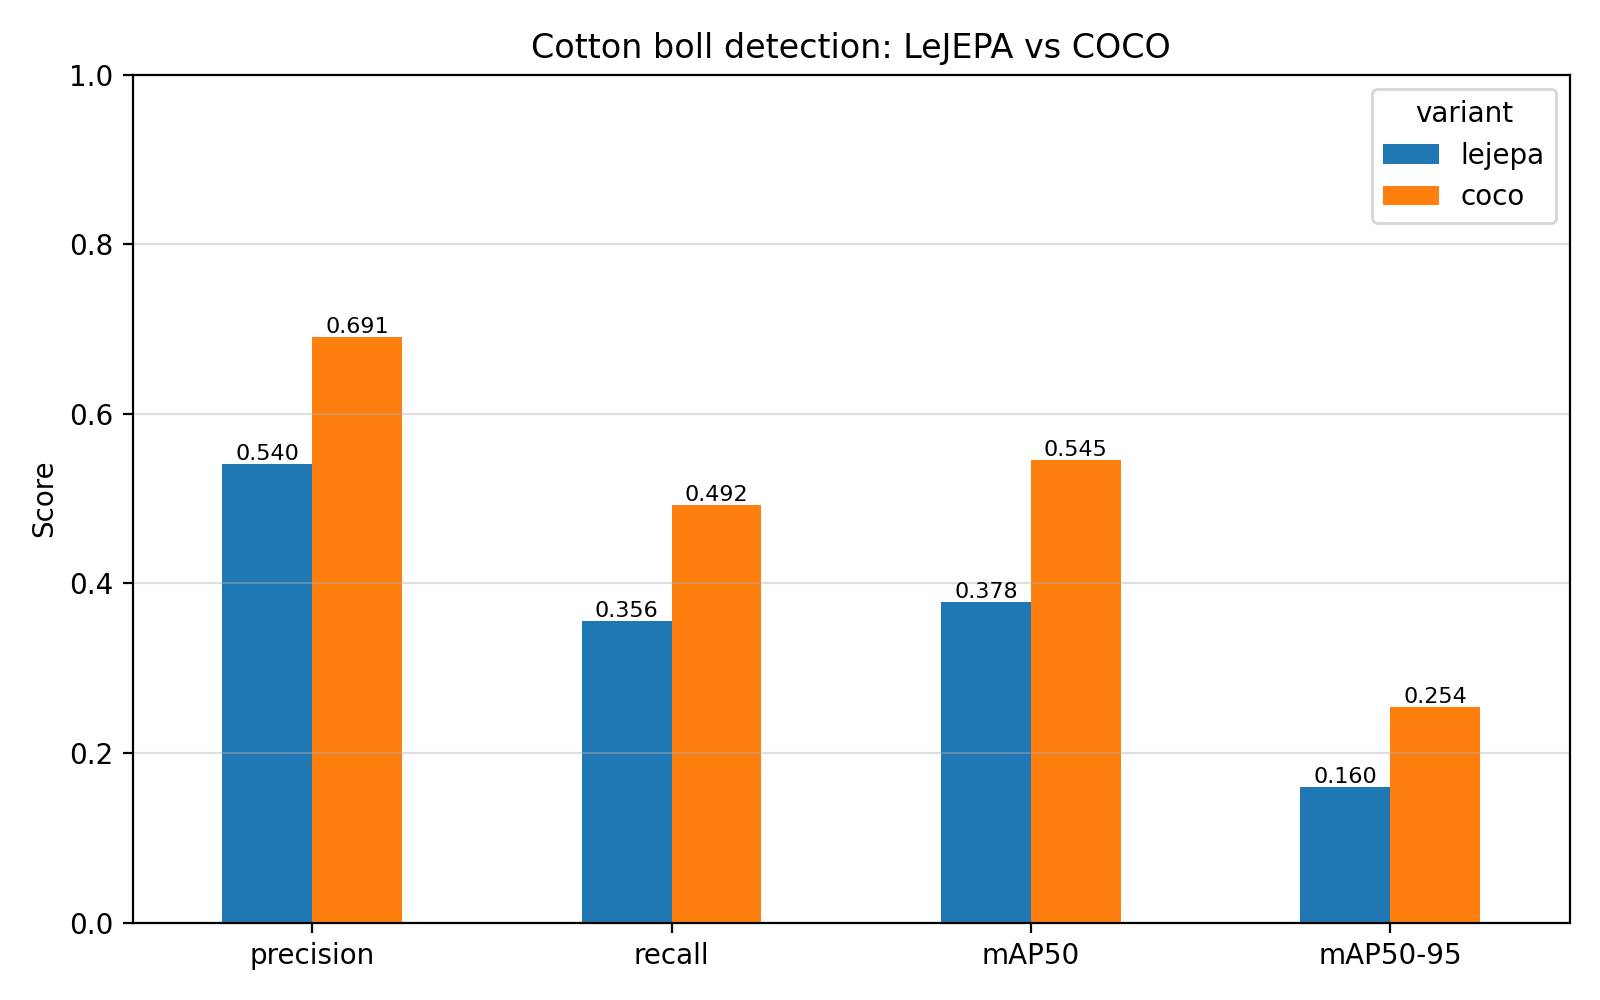

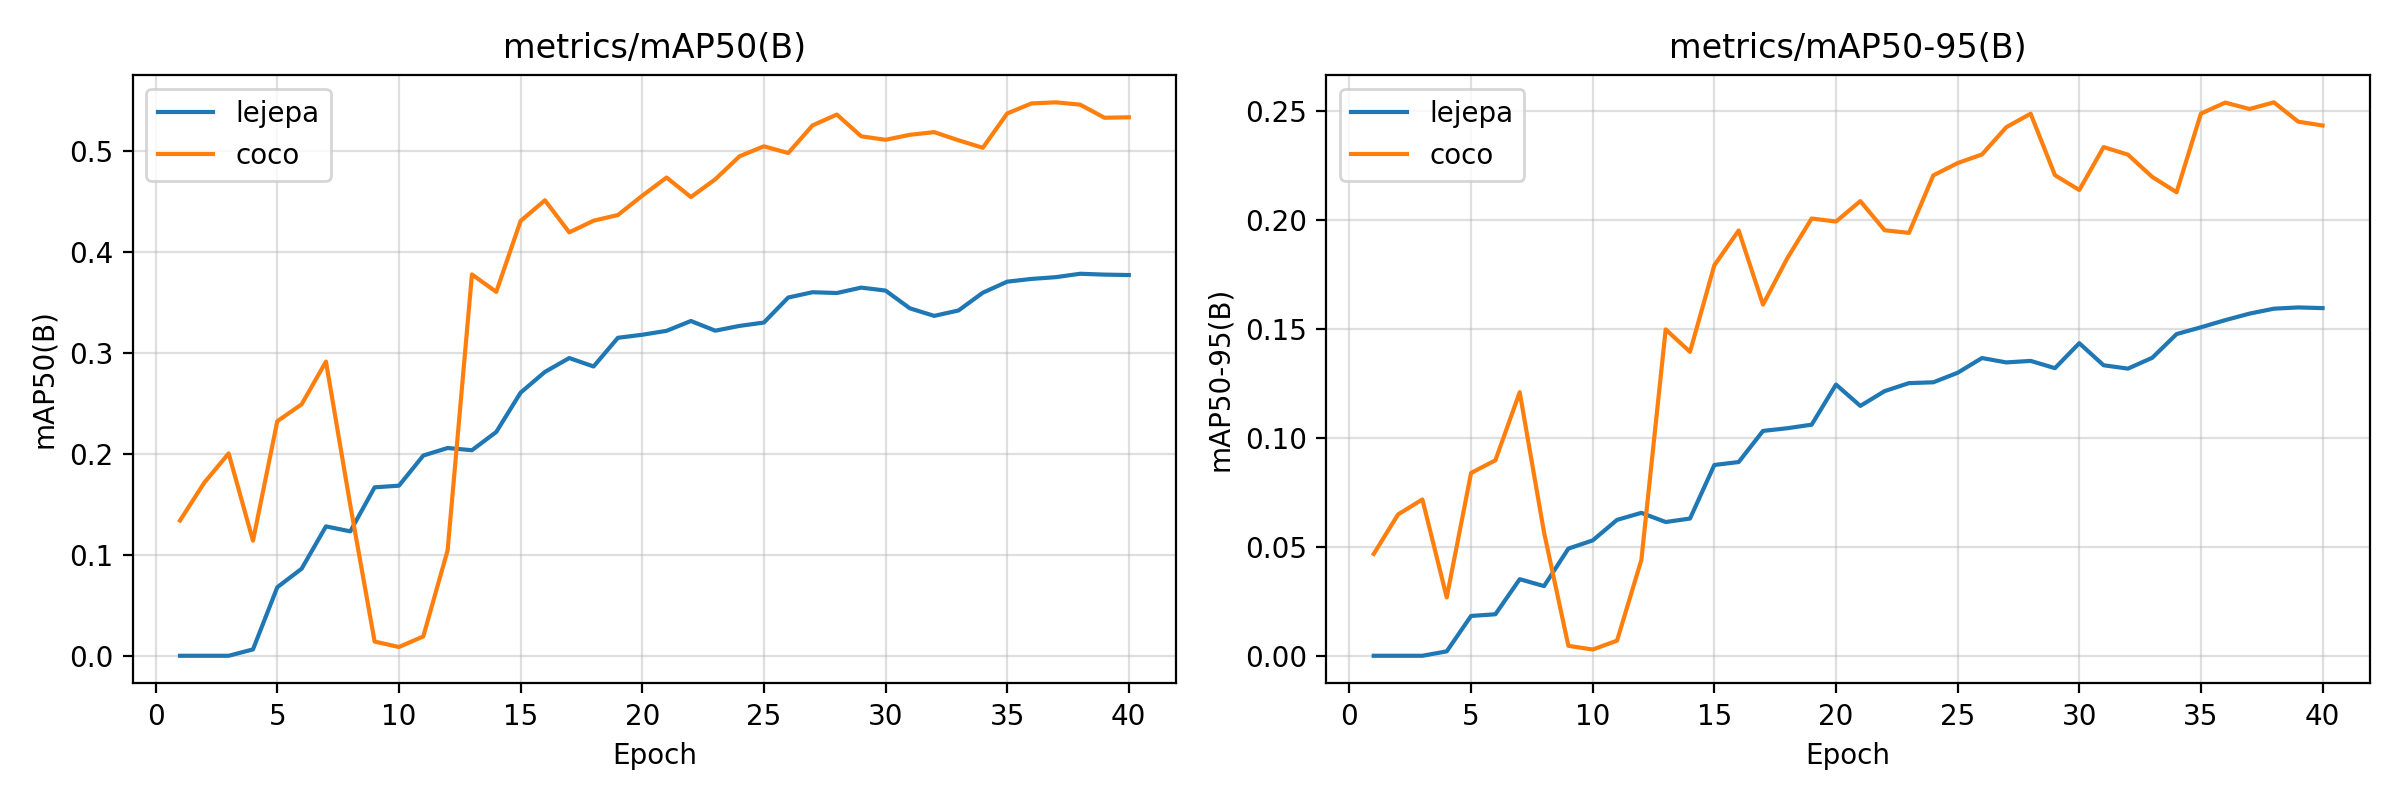

Box overlays (green = ground truth, red = prediction): /Users/akintanoreofeoluwa/lejepa_cotton_outputs/detection/overlays


In [12]:
display(Image(filename=str(detection_cfg.output_dir / "plots" / "detection_metrics.png")))
display(Image(filename=str(detection_cfg.output_dir / "plots" / "detection_curves.png")))
print("Box overlays (green = ground truth, red = prediction):", detection_cfg.output_dir / "overlays")

## 5. Evaluation B - plot-status linear probe on frozen GAP features (LeJEPA vs COCO)
The backbone is frozen (including BatchNorm statistics); only a linear layer is trained on the concatenated P3/P4/P5 GAP vectors.

In [13]:
probe_summary = run_probe_evaluation(probe_cfg)
probe_summary

Plot status data: 177 labelled images of 867 (annotations: annotations.json), class counts {0: 35, 1: 71, 2: 71}.
Probe split: 88 train (of 88 available) | 89 test

[lejepa] linear probe on test split
               precision    recall  f1-score   support

     headland     0.6667    0.7059    0.6857        17
between_plots     0.6857    0.6667    0.6761        36
      in_plot     0.8333    0.8333    0.8333        36

     accuracy                         0.7416        89
    macro avg     0.7286    0.7353    0.7317        89
 weighted avg     0.7418    0.7416    0.7415        89


[coco] linear probe on test split
               precision    recall  f1-score   support

     headland     0.7333    0.6471    0.6875        17
between_plots     0.6750    0.7500    0.7105        36
      in_plot     0.8529    0.8056    0.8286        36

     accuracy                         0.7528        89
    macro avg     0.7538    0.7342    0.7422        89
 weighted avg     0.7581    0.7528    0.7539

,variant,accuracy,macro_f1
0,lejepa,0.741573,0.731701
1,coco,0.752809,0.742199


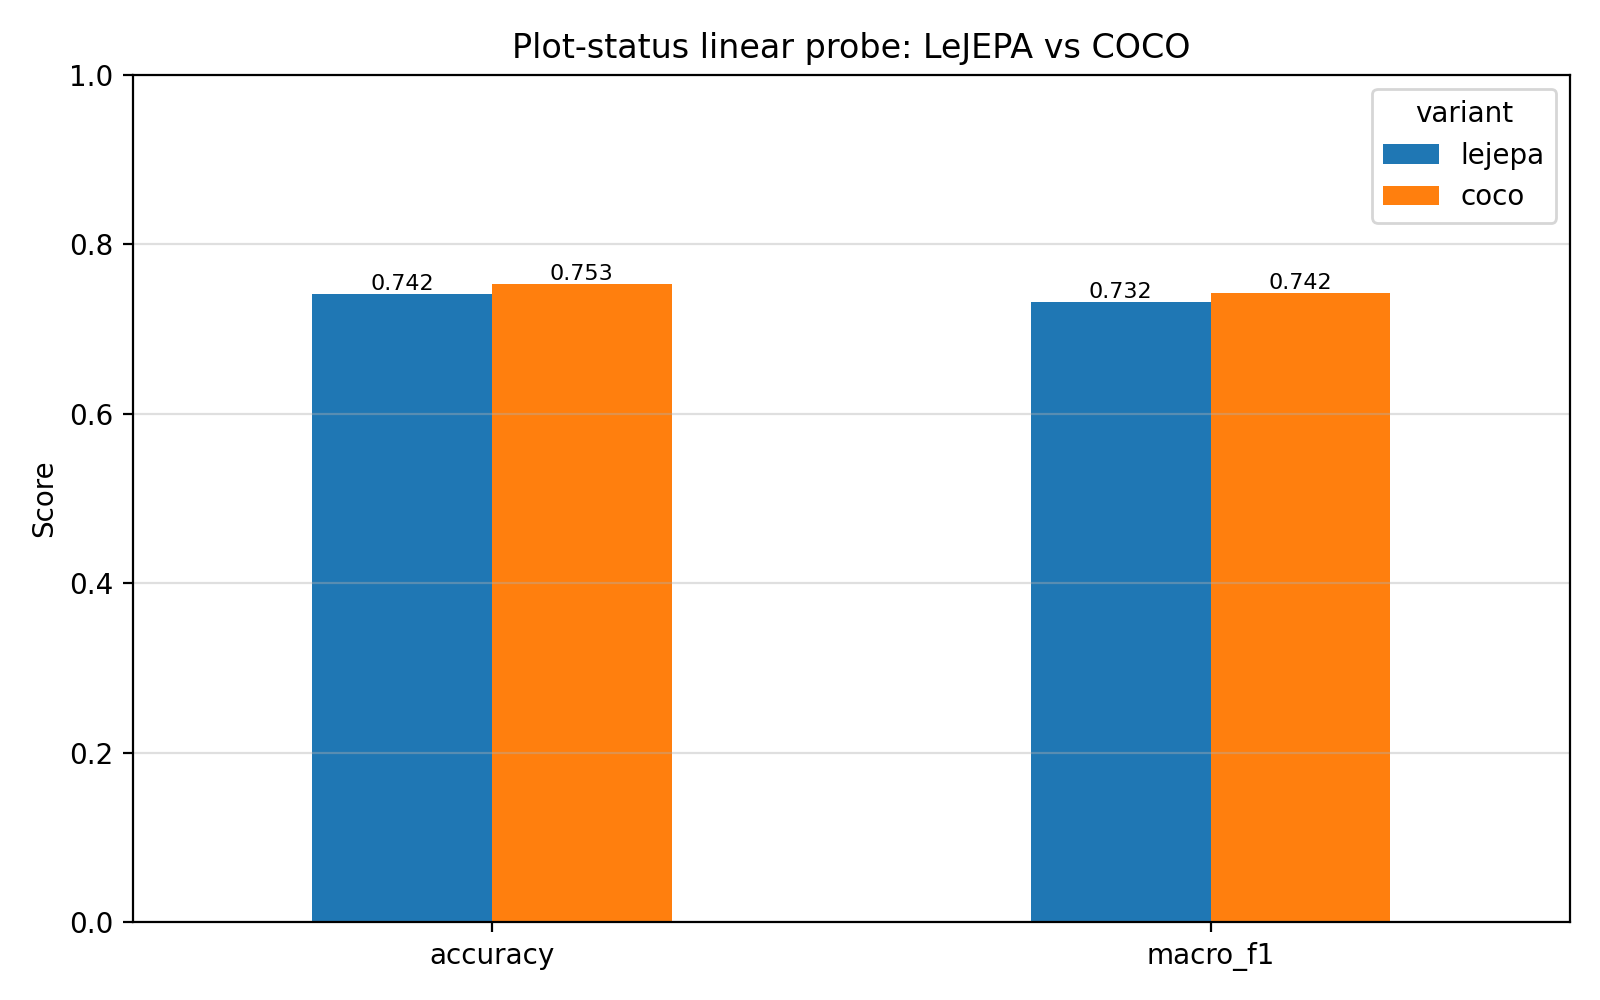

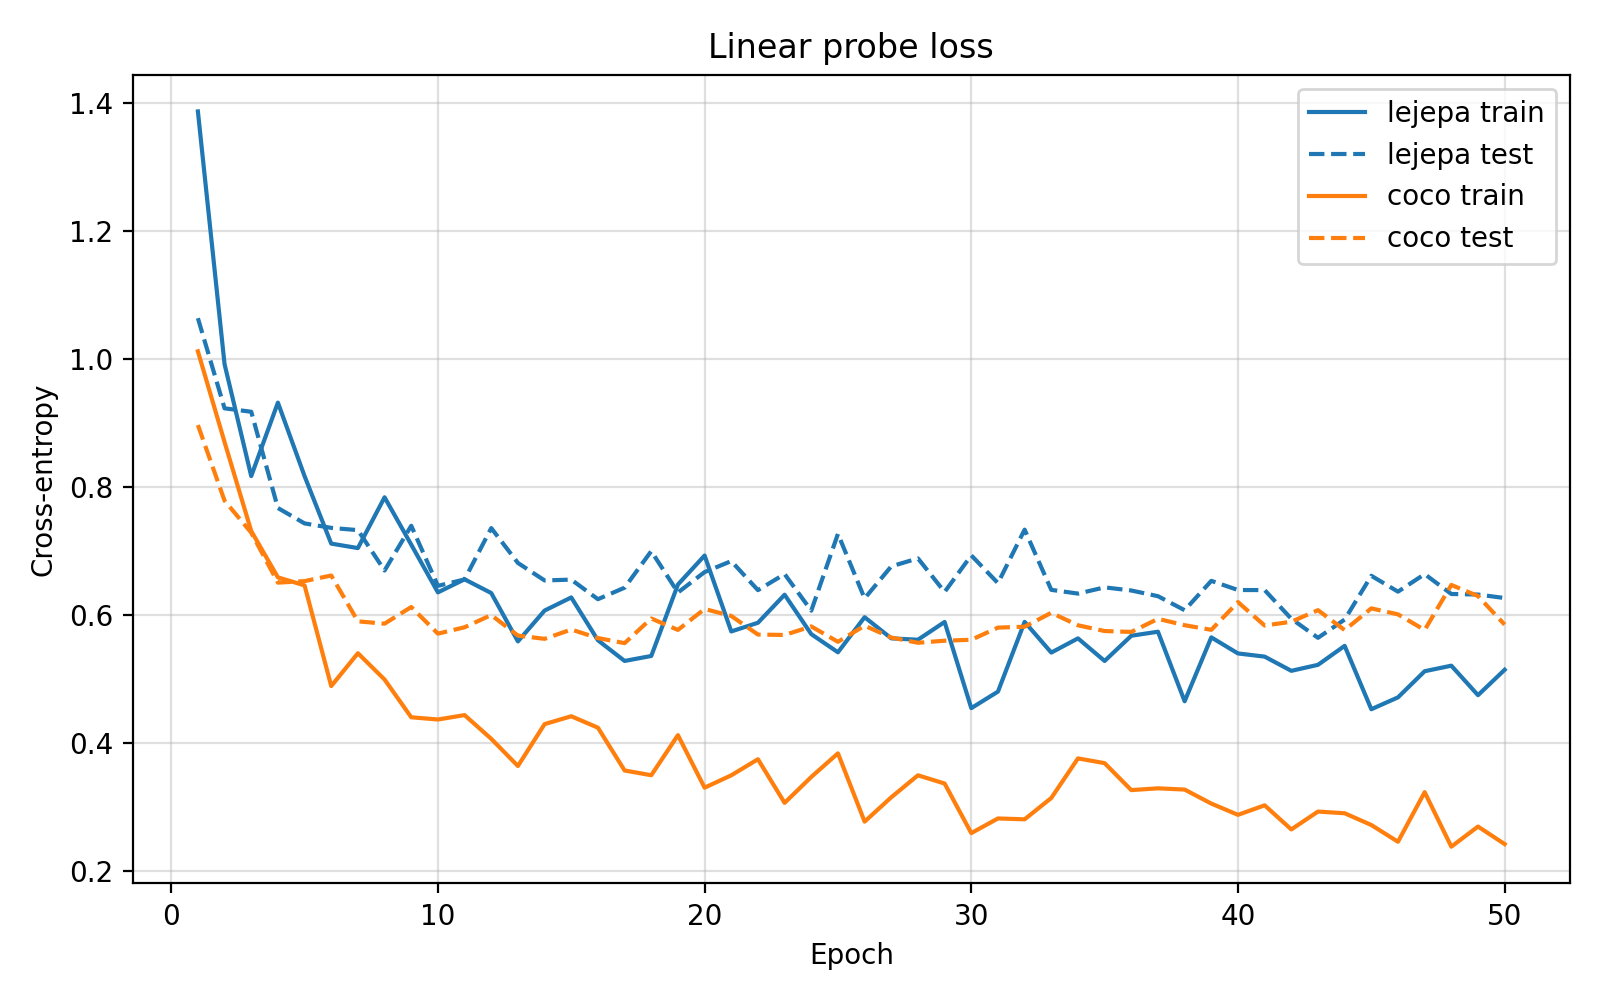

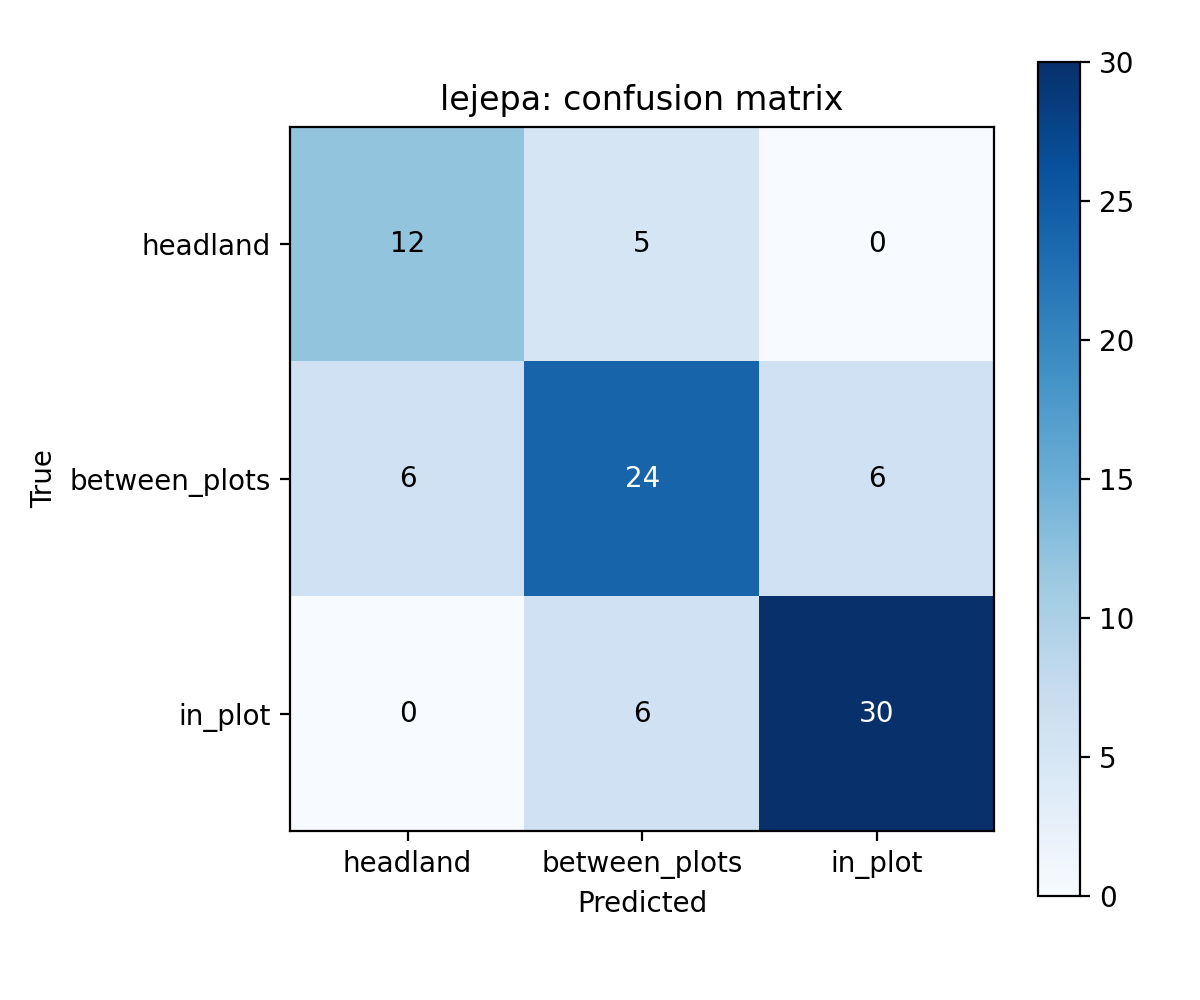

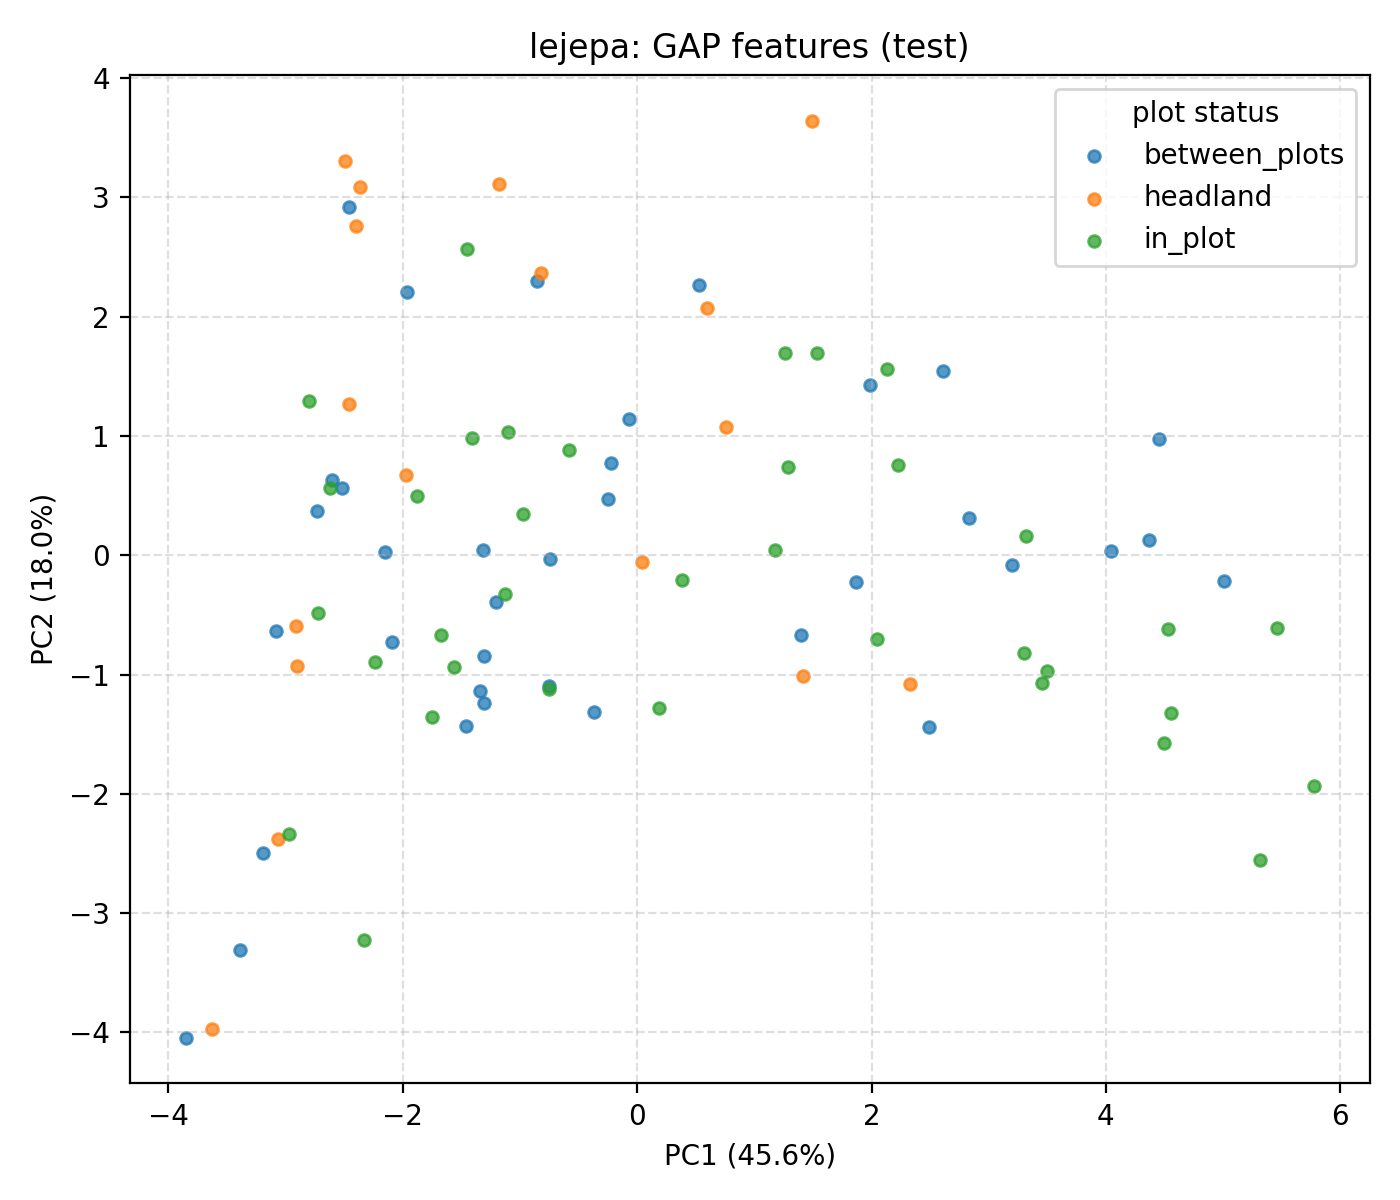

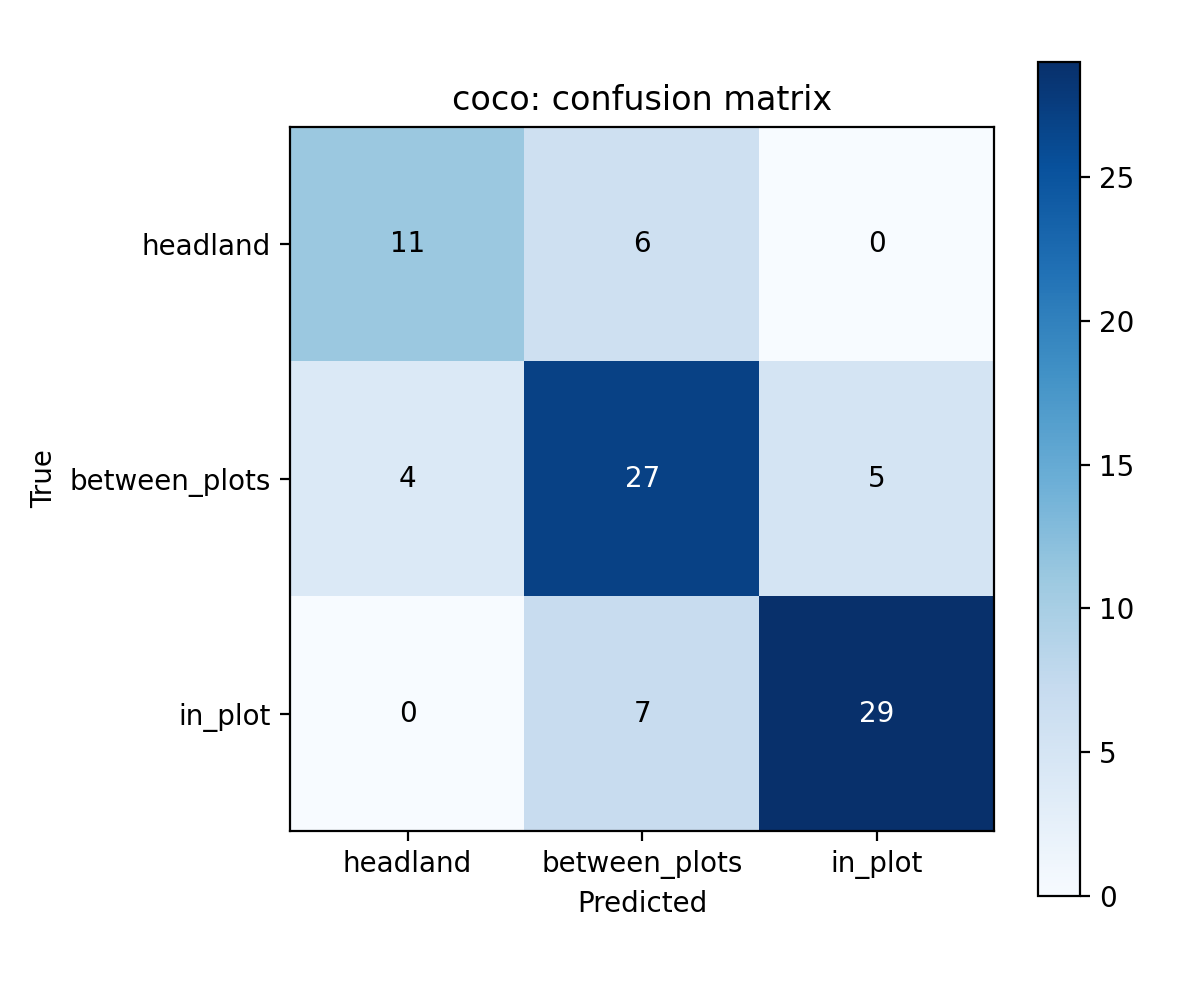

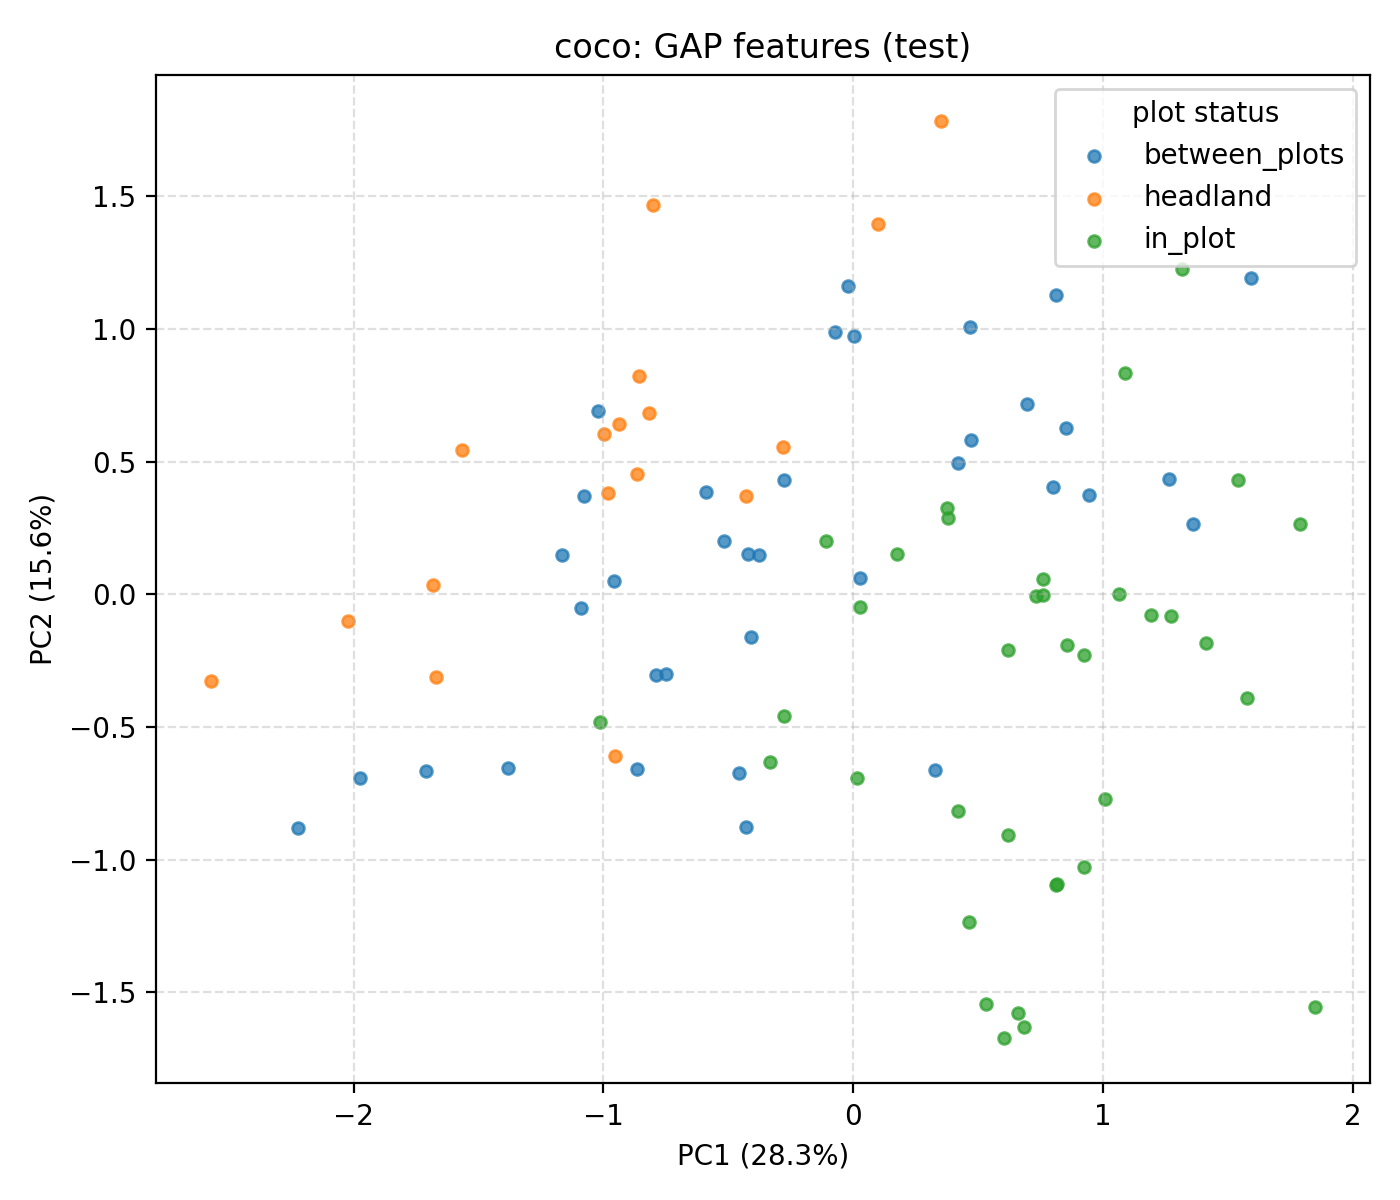

In [14]:
probe_plots = probe_cfg.output_dir / "plots"
display(Image(filename=str(probe_plots / "probe_metrics.png")))
display(Image(filename=str(probe_plots / "probe_loss_curves.png")))
for variant in probe_cfg.variants:
    display(Image(filename=str(probe_plots / f"confusion_{variant}.png")))
    display(Image(filename=str(probe_plots / f"pca2d_{variant}.png")))